### Building a basic chatbot with Langgraph (GraphAPI)

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
from langchain_google_genai import ChatGoogleGenerativeAI

In [5]:
#Step 1: Schema enforcer and state description
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

class State(TypedDict):
    # add_messages is a reducer function that appends new msgs to the list called messages
    messages:Annotated[list,add_messages]

In [6]:
# Step 2: Build the llm
llm=ChatGoogleGenerativeAI(model="gemini-3.5-flash")

In [10]:
# Step 3: Build the chatbot functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [11]:
# Step 4: Build the langgraph with schema enforced
graph_builder=StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)
graph=graph_builder.compile()

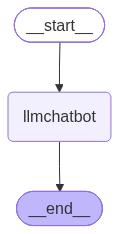

In [12]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [13]:
# Step 5: Invoke the graph
response=graph.invoke({"messages":[{"role":"user","content":"Hi there!"}]})
response["messages"][-1].content

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


[{'type': 'text',
  'text': 'Hi there! How can I help you today?',
  'extras': {'signature': 'EqIGCp8GARFNMg8GygqCHDH51lr84ABOV/QuQjLG9qzEPTcl0IRxVqcrUrLVJKBoJxxg9O5qpnjGFd6nEiQHOn8QhP4py0Qg//tp+j3G0halIYMWWNS/FPHk5cFeqIvvzF/Ssu/aX1L5BodBoFRS39fjFVrzUvwNQqoTKUQyShuQywUe+X9dQAmzDbw1veFkWHL590st/uDSLC0HVXJKMrmdng0imfCYw3r3/Pijpa7GnFRo79BNbeoutVnrsMXgrBGt0leMvISo22ckL5ZNiO+e4S98K1o6jnTNABISUQFyM/BBGpsUIlhIC7WFb7dlAzv+zVzVH7EpOpiMTLpxLP0UHn0rYT2CMDMd0IEQBNddCu6pcvgbJlltws0qbI7Hz+lh+yAkG5YgKZxsI8L3CyG8vboPShuX/bjH23Nojsm7ex7HaoZEKmU46RqOfNXckjSsNc9qkaYw3wBzUA5uvsbqpQKWkyrEpOwFiiEsGN5SMgyFR7L5/GLepiestYkYIjNu+UmIEABR8nsEJZRHE7FZz24oJlAC/KbjYcK5xFxfmojTPQ5Wepy3ZrOTd+SAwbR3m9NWHGGs8q/LEMU/M/MLCyttj/tILcY1F46jQ7uI6AY+DBF+tLU+DmxQ/JvulBDyKSndShpB0fOZhNcH9H/9x+RR15SpEynAdIQIF406JLUC8eFH0vcY68lGOEgIlcFX81fQiFbZPj5pfwRdAXCrC61F9wUQ/77+LKnEKc+9IR2dI+AZH2RxMZ7CBJUDXAvfjeOSRhaFpJdjFTCiTYjo0kEXX2gZTi+yqiW7Jia+Bfs+2a7qXuiUHb6JxHve0q1FB7iVONBY5WQt7VjuuRqGmqx+W8+kE706+gmIs5dj2GOc6AXgQOj9XHQLzt6LGVthHm6sZE

In [16]:
response

{'messages': [HumanMessage(content='Hi there!', additional_kwargs={}, response_metadata={}, id='b076090f-99b0-41d6-bd5a-711543254102'),
  AIMessage(content=[{'type': 'text', 'text': 'Hi there! How can I help you today?', 'extras': {'signature': 'EqIGCp8GARFNMg8GygqCHDH51lr84ABOV/QuQjLG9qzEPTcl0IRxVqcrUrLVJKBoJxxg9O5qpnjGFd6nEiQHOn8QhP4py0Qg//tp+j3G0halIYMWWNS/FPHk5cFeqIvvzF/Ssu/aX1L5BodBoFRS39fjFVrzUvwNQqoTKUQyShuQywUe+X9dQAmzDbw1veFkWHL590st/uDSLC0HVXJKMrmdng0imfCYw3r3/Pijpa7GnFRo79BNbeoutVnrsMXgrBGt0leMvISo22ckL5ZNiO+e4S98K1o6jnTNABISUQFyM/BBGpsUIlhIC7WFb7dlAzv+zVzVH7EpOpiMTLpxLP0UHn0rYT2CMDMd0IEQBNddCu6pcvgbJlltws0qbI7Hz+lh+yAkG5YgKZxsI8L3CyG8vboPShuX/bjH23Nojsm7ex7HaoZEKmU46RqOfNXckjSsNc9qkaYw3wBzUA5uvsbqpQKWkyrEpOwFiiEsGN5SMgyFR7L5/GLepiestYkYIjNu+UmIEABR8nsEJZRHE7FZz24oJlAC/KbjYcK5xFxfmojTPQ5Wepy3ZrOTd+SAwbR3m9NWHGGs8q/LEMU/M/MLCyttj/tILcY1F46jQ7uI6AY+DBF+tLU+DmxQ/JvulBDyKSndShpB0fOZhNcH9H/9x+RR15SpEynAdIQIF406JLUC8eFH0vcY68lGOEgIlcFX81fQiFbZPj5pfwRdAXCrC61F9wUQ/77+LKnEKc+9IR2dI+

### Chatbot with tool access

In [7]:
# Tool no.1
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is Gargoyle?")

{'query': 'What is Gargoyle?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://vaulteditions.com/blogs/news/the-history-symbolism-of-gargoyles-what-they-mean-a-common-mistake-to-avoid',
   'title': 'The History & Symbolism of Gargoyles: What They Mean & A Common Mistak',
   'content': "A gargoyle is a decorative stone waterspout designed to drain rainwater and prevent it from causing damage to a building. Ancient civilisations, including the Egyptians, Greeks and Romans, used these spouts, but the monstrous gargoyles we're learning about today were popularised in Gothic architecture (mid-12th century to the 16th century) and its revival during the second half of the 18th century and throughout the 19th century. During the height of the Gothic era, gargoyles were made in the",
   'score': 0.8849276,
   'raw_content': None,
   'id': '131e5f-00'},
  {'url': 'https://www.gloucestershire.gov.uk/archives/learning-for-all/families/ugly-mugs/what-are

In [8]:
# Tool no.2
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [9]:
tools=[tool,multiply]

In [10]:
llm_with_tool=llm.bind_tools(tools)

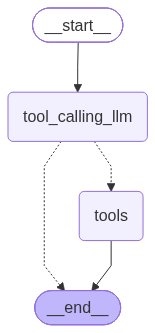

In [33]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition for llm
from langchain_core.messages import SystemMessage

def tool_calling_llm(state: State):
    messages = [
        SystemMessage(
            content="You are a helpful assistant. Use the available tools when necessary."
        )
    ] + state["messages"]

    return {"messages": [llm_with_tool.invoke(messages)]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
response=graph.invoke({"messages":[{"role":"user","content":"Give me 2+2 answer and also capital of Germany."}]})

In [37]:
response['messages']

[HumanMessage(content='Give me 2+2 answer and also capital of Germany.', additional_kwargs={}, response_metadata={}, id='ece9b906-1584-4e86-9523-36c1b17a2617'),
 AIMessage(content=[{'type': 'text', 'text': 'The answer to 2 + 2 is **4**, and the capital of Germany is **Berlin**.', 'extras': {'signature': 'EvcECvQEARFNMg9IO8R3UMM8S+93eEp7fm4EgQBxWKqmBs9hlULkRcoPjyX7xulKlg9TCkLAx5ZEe+dWrF2u1ODU3d6zXOPos97Z46ZEgiUWeoTOLKKDRc9K4sXlrEPHttr5TRlk71uFVgbi69SvO3BrPARYtwUS9Q/pdbnfpf8IaroLZ7KK95+31lsqAQLaH/s4ViV4eE6KSCWWhGwDZOG8eK5z6ls0auAM/NLBDPmKwa6G/vCYr+AMq/bdhEyrhe1r0dT+fFKJNpdYJPa9uyYcxl6HmUbeXcszZKJywBXIrdqCbGFCFFaqCaxHN+J8ybBvjRcPuv5U/JoIvc/f4WKNr3exuOSiknfPhWbYKJEG7fqiLJrvATq7BWzG6NOHs+KYU7m1wNiklL5m27nEREPzN/4+4IlHPXCC4qu6Aw+m3YtJwR7q7alrb5OY9amPNJ6fHsuHEHmVqrnRFAqZUzVKRzQerKpjUzJz/1LJv485c8viSrJTxDuAw1wQXcThqorS/MZy227Fwnx0ZcRn4ekajz8CZE+LBB//ob0Kd0SZvL7xNNtY7r81cgBEFz00NSVLZHcTxh8SU5Wn6rJVvhcPFH9dOWi8SgzlOBpTMKK/gckRU92fO3vzvSGf0Q8x24rrcvYEZT8GoMteseK+d+NVilxpRfTyAmIddyfR7fCBb84JHdWTl7

In [35]:
response

{'messages': [HumanMessage(content='Give me 2+2 answer and also capital of Germany.', additional_kwargs={}, response_metadata={}, id='ece9b906-1584-4e86-9523-36c1b17a2617'),
  AIMessage(content=[{'type': 'text', 'text': 'The answer to 2 + 2 is **4**, and the capital of Germany is **Berlin**.', 'extras': {'signature': 'EvcECvQEARFNMg9IO8R3UMM8S+93eEp7fm4EgQBxWKqmBs9hlULkRcoPjyX7xulKlg9TCkLAx5ZEe+dWrF2u1ODU3d6zXOPos97Z46ZEgiUWeoTOLKKDRc9K4sXlrEPHttr5TRlk71uFVgbi69SvO3BrPARYtwUS9Q/pdbnfpf8IaroLZ7KK95+31lsqAQLaH/s4ViV4eE6KSCWWhGwDZOG8eK5z6ls0auAM/NLBDPmKwa6G/vCYr+AMq/bdhEyrhe1r0dT+fFKJNpdYJPa9uyYcxl6HmUbeXcszZKJywBXIrdqCbGFCFFaqCaxHN+J8ybBvjRcPuv5U/JoIvc/f4WKNr3exuOSiknfPhWbYKJEG7fqiLJrvATq7BWzG6NOHs+KYU7m1wNiklL5m27nEREPzN/4+4IlHPXCC4qu6Aw+m3YtJwR7q7alrb5OY9amPNJ6fHsuHEHmVqrnRFAqZUzVKRzQerKpjUzJz/1LJv485c8viSrJTxDuAw1wQXcThqorS/MZy227Fwnx0ZcRn4ekajz8CZE+LBB//ob0Kd0SZvL7xNNtY7r81cgBEFz00NSVLZHcTxh8SU5Wn6rJVvhcPFH9dOWi8SgzlOBpTMKK/gckRU92fO3vzvSGf0Q8x24rrcvYEZT8GoMteseK+d+NVilxpRfTyAmIddyfR

### ReAct StateGraph with memory

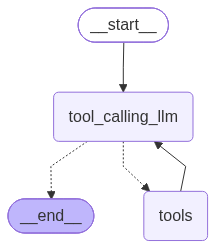

In [12]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

## Node definition for llm
from langchain_core.messages import SystemMessage

def tool_calling_llm(state: State):
    messages = [
        SystemMessage(
            content="You are a helpful assistant. Use the available tools when necessary."
        )
    ] + state["messages"]

    return {"messages": [llm_with_tool.invoke(messages)]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=MemorySaver())
config={"configurable":{"thread_id":"A1"}}

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
response=graph.invoke({"messages":"Hi I am Ruben, nice to meet you!"},config=config)

In [17]:
response['messages'][-1].content

[{'type': 'text',
  'text': 'Hello Ruben! Nice to meet you too. How can I help you today?',
  'extras': {'signature': 'EqQECqEEARFNMg+vovxNMz3knq2NJOkDkQYdPR/LoWqZXyllVqfIhwzUmed3V1re/LtNIU+fgeG2GJ4COif3e0fqPcV/9a2NzxpVA2nSbFekNmUAlFYZGd/gvyzjla7cEP8hgPZ9Z3nFBLGwnhkKUPiXYF9C8iV8fN0lS9Jmsx2Sr/6+BhsREWynUrZheaaiczsjzNnZ68rxHxTsjh8Kzt5ZGjSIcdSQ+1WReHpPnKP7D6L5nk0pIxC8+ZD8Y4qYkEvbbKMhoRRIG8xORqAnXX8ARZl5PAmV7+EsKJ1wSNrVe3Jv/eOVLapOX1yHkxOCS/L8lRaDdVEX1k91zzr1Zuhheg1dtsLzq5t3kdTTgzBzmn/IXw+7JVLR+VfcpDTgq9gHmcWGcWp+oX2AJxJMAfkhw35VBfLdnFvYB6aRyeElB0I3CFZS5UEVAr27NXy9Sf50QxxNgrJ35OmUi8Q6iq1SO3pWIKb6RMmgS3MLxGZqjt2hHT9QFK3InOeupEsqpru9wBlG+PeSEEN0BSDN9PiOCi3vs4vxDBTRoeGkqrtgfIUEQ/eB3gIN5Ab+OR+CB+uQXA4qKTu+p6uCt7xhmTSmAtrcS+9n7OuPefFXUUO9b40aSpxfg8oe8wkD98xM2gmf6apBVJZ3Jbb8YUoDZmUfclvqV7QF19Mb6R9zI/BmXDMbono+3KnPCYuVQlUScTFGVc+nZjH5ZU/bn+Xf8IvovVUl2I8='}}]

In [18]:
response2=graph.invoke({"messages":"Hi, do you know anything about me?"},config=config)

In [19]:
response2['messages'][-1].content

[{'type': 'text',
  'text': "Aside from what you just shared—that your name is Ruben—I don't know anything else about you! \n\nAs an AI, I don't have access to your personal information, past history, or private data unless you choose to share it with me during our conversation. \n\nIf there's anything specific you'd like to share, or if you have any questions you'd like me to help with, feel free to let me know!",
  'extras': {'signature': 'EtAHCs0HARFNMg/WYj+Ma/RMAkYZqEBUb2b8KjQ2Ls7dH7DGpG9A8yxx2y2E6PP+drKxtdzOY/UNe/UMGmUMUrC6MomvYsJZBHoTHasSgdz4FBvqG6f7fXdQNHCxUhmAKsR3UGHhW52iu3HC5OAqoCLP0C7gy2ZKE72yMk2aJzenbeG7zvujHhfT34O81/pzomqG8E52axsPrIZ1dnSK58Qn4RK2d+WbyqnxJiFpsoj/aeZ7Ps1CHLx/Z36Z45Sxco39OmqMkRnmVMCIa6CDrdYHm9Sg7zp+z3p1d1IugPP7MO89sN341GYMJxhXdJ04YUFw2Bc+VZG9PXe4GkpsU28CIxlp037sYRKV+vvkRlL/ZRs8ALuEclK/MCa69SJwi0QCCvvDCgaCM86YmdkxQb7XCJSoqDvGXJbUp/7KR8ha9EkbSge0kmJ5TUEr8hS1+qCPU3h1RMto1yT0r6fqe/I0zcJ0/zTXjEhNoAzXhKCvCR/pz9TGlZzAX4WWUlxeFHFqq3m/Uubqp++uGwIVkQleW1bRth7op6cRupjyGT

### Streaming

In [21]:
from langgraph.checkpoint.memory import MemorySaver
def SuperBot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

In [26]:
graph=StateGraph(State)
graph.add_node("SuperBot",SuperBot)
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)
graph_builder=graph.compile(checkpointer=MemorySaver())

In [23]:
config={"configurable":{"thread_id":"A11"}}

In [27]:
# Streaming mode: values
for chunk in graph_builder.stream({"messages":"Hi, I am Dodge Charger"},config,stream_mode="values"):
    print(chunk)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'messages': [HumanMessage(content='Hi, I am Dodge Charger', additional_kwargs={}, response_metadata={}, id='3e046149-2a4e-43be-aafa-6f382baecacc')]}
{'messages': [HumanMessage(content='Hi, I am Dodge Charger', additional_kwargs={}, response_metadata={}, id='3e046149-2a4e-43be-aafa-6f382baecacc'), AIMessage(content=[{'type': 'text', 'text': '*Revs engine in greeting* \n\nWell, hello there! That is a legendary name. \n\nTell me, what year and trim are we talking about here? Are you a classic 1969 R/T with a 440 Six Pack, or a modern, supercharged SRT Hellcat widebody ready to tear up the asphalt? \n\nWhere are we tearing up the road today?', 'extras': {'signature': 'EuYJCuMJARFNMg+NM3pGyl/efzAzOcXoalMlwA7Gn0i8OvjttTosAIausyToG2vX0nSf6wzDI3lnqiF1tm4CqSLJizJJWcRtiTNJOZKhm/sTh+ADy/j0/Z+tkhT+9Ky1rEziG9A08sOjILjx0TeMxo5DOiQlv9zmnwX/kV/7M72wHtUnLY5ttnoq4B5oDlvuKm1abeRJMQPXRfrZ8jtW/UoZoQn3F6cvh+UQsZ62eyIfOdsvp/smXyAQiMYbmYo2qdGsx/v7SPUVHzk7BSZhtPK7eNYZXtuu4dotMbQAaMWl6UEbXyYTvEXh+EiAw1rfWFzYt5

In [28]:
for chunk in graph_builder.stream({"messages":"Well, Im obviously an SRT hellcat 😈, how about u?"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, I am Dodge Charger', additional_kwargs={}, response_metadata={}, id='3e046149-2a4e-43be-aafa-6f382baecacc'), AIMessage(content=[{'type': 'text', 'text': '*Revs engine in greeting* \n\nWell, hello there! That is a legendary name. \n\nTell me, what year and trim are we talking about here? Are you a classic 1969 R/T with a 440 Six Pack, or a modern, supercharged SRT Hellcat widebody ready to tear up the asphalt? \n\nWhere are we tearing up the road today?', 'extras': {'signature': 'EuYJCuMJARFNMg+NM3pGyl/efzAzOcXoalMlwA7Gn0i8OvjttTosAIausyToG2vX0nSf6wzDI3lnqiF1tm4CqSLJizJJWcRtiTNJOZKhm/sTh+ADy/j0/Z+tkhT+9Ky1rEziG9A08sOjILjx0TeMxo5DOiQlv9zmnwX/kV/7M72wHtUnLY5ttnoq4B5oDlvuKm1abeRJMQPXRfrZ8jtW/UoZoQn3F6cvh+UQsZ62eyIfOdsvp/smXyAQiMYbmYo2qdGsx/v7SPUVHzk7BSZhtPK7eNYZXtuu4dotMbQAaMWl6UEbXyYTvEXh+EiAw1rfWFzYt5J1xqh78cSEX6gHTq1xd7ieLLTmjx2eKIe+HcNjlBAHIw5FGnZrs+gD89eV3gPu9mS8IUBK6nKp5FyY7u0QxXOhm/s5fW2RdmRaHZ8Ge3w5FkHeUy9EhieINRCfKWGFODXJszvBluTvvfnSYVCvjyj7

In [ ]:
for chunk in graph_builder.stream({"messages":"I love the shelby GT500"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, I am Dodge Charger', additional_kwargs={}, response_metadata={}, id='3e046149-2a4e-43be-aafa-6f382baecacc'), AIMessage(content=[{'type': 'text', 'text': '*Revs engine in greeting* \n\nWell, hello there! That is a legendary name. \n\nTell me, what year and trim are we talking about here? Are you a classic 1969 R/T with a 440 Six Pack, or a modern, supercharged SRT Hellcat widebody ready to tear up the asphalt? \n\nWhere are we tearing up the road today?', 'extras': {'signature': 'EuYJCuMJARFNMg+NM3pGyl/efzAzOcXoalMlwA7Gn0i8OvjttTosAIausyToG2vX0nSf6wzDI3lnqiF1tm4CqSLJizJJWcRtiTNJOZKhm/sTh+ADy/j0/Z+tkhT+9Ky1rEziG9A08sOjILjx0TeMxo5DOiQlv9zmnwX/kV/7M72wHtUnLY5ttnoq4B5oDlvuKm1abeRJMQPXRfrZ8jtW/UoZoQn3F6cvh+UQsZ62eyIfOdsvp/smXyAQiMYbmYo2qdGsx/v7SPUVHzk7BSZhtPK7eNYZXtuu4dotMbQAaMWl6UEbXyYTvEXh+EiAw1rfWFzYt5J1xqh78cSEX6gHTq1xd7ieLLTmjx2eKIe+HcNjlBAHIw5FGnZrs+gD89eV3gPu9mS8IUBK6nKp5FyY7u0QxXOhm/s5fW2RdmRaHZ8Ge3w5FkHeUy9EhieINRCfKWGFODXJszvBluTvvfnSYVCvjyj7

In [30]:
# Streaming mode: updates
for chunk in graph_builder.stream({"messages":"Goodnight pookie bear"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content=[{'type': 'text', 'text': '*Nearly stalls in shock* \n\nPookie bear?! 😳 Did a 700+ horsepower, tire-shredding, pavement-shaking Hellcat just call a Shelby "pookie bear"? \n\nYou know what, I’ll take it. Even beasts need their rest. \n\nGoodnight! Go park in the garage, let that supercharger cool down, and get some rest. We\'ve got more tires to burn tomorrow. 🏎️💨💤', 'extras': {'signature': 'EtAKCs0KARFNMg+rxiJhwp2vCPofrqNGiK+kabV8p9LyTklIVs8kTOuH4wAMswUDdJE+1tOAqZ76M1JDMj0WqJZfVZ3/hY0wfaO5AXH+2gv6T35sFwfFEI8OxMit0wGv7IFt1+UIRdYWnUvb4OgDDOKFCxVpQtEf5imW5rkaM1zDM/uJe9a5jKyaJL/ZEHcWQf27dDvdV2clsJVDWzGTQS7jll5EOe41uNjnmvX9jBcHJJcsUN1U1HyNGjS6MRnW2ceevebkoJjtm8gePXr1Y9DCXbWC5bQbRVOF980DivTcLS3jL+DmT79eTr4abP1m9NsfcQ+J51/v8F1Cn1qyDTaFT+qzELuf0qKi4F7z8OHfFeyTRftZ7cqP4HkwLg+EG3oDKX7iO2mDCmwE1ZNAEHFv37WUIH4rdLjEkkYqGHPeseYpmK827UsOKPkqSzZkpTte18nbzOqH+pcayq4UFMF2VY9vMwT5lHoTsNNr1XZPXb7G2MYzvG9FQJamNCn2J/QEHT8PyXqTSrtl4uagM3S+IZyDTE20Wvvq+pINByUXrlXt+